## Group-aware Sampling
In large dataset with groups, choice of the sampling method may depend on the number of groups and the group size. 

In this example we consider line plot where each line correspons to a group.


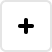
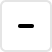
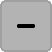
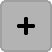
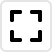
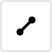
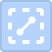
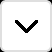
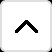
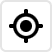
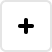
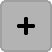
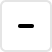
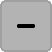
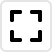
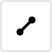
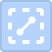
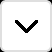
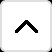
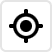

In [1]:
import numpy as np
from lets_plot import *

LetsPlot.setup_html()

In [2]:
def data(n_per_line, n_groups):
    x_step = 2 * np.pi / (n_per_line - 1)
    little_delta = x_step / 100
    x_stops =np.arange(-np.pi, np.pi + little_delta, x_step)

    y_min, y_max = 1, 10
    y_step = (y_max - y_min) / (n_groups - 1)
    little_delta = y_step / 100
    y_multiplier = np.arange(y_min, y_max + little_delta, y_step)

    x = []
    y = []
    c = []
    for i in range(n_groups):
        x.extend(x_stops)
        y.extend([np.sin(x) * y_multiplier[i] for x in x_stops])
        c.extend([str(i) for _ in x_stops])

    return dict(x = x, y = y, cond = c)

In [3]:
p = ggplot(mapping=aes('x','y',color='cond'))

### 1. Data with large number of points per group but small number of groups.

In [4]:
n_per_line, n_groups = 1000, 10
dat = data(n_per_line, n_groups)

In [5]:
# The default 'systematic' sampling is fine in this case.
p + geom_line(data=dat)

### 2. Data with small number of points per group but large number of groups.

In [6]:
n_per_line, n_groups = 30, 1000
dat = data(n_per_line, n_groups)

In [7]:
# The default systematic line sampling doesn't work very well in this case.
p + geom_line(data=dat)

In [8]:
# Random group sampling works better.
p + geom_line(data=dat, sampling=sampling_group_random(10))

In [9]:
# Systematic group sampling works even better.
p + geom_line(data=dat, sampling=sampling_group_systematic(10))

### 3. Data with large number of points per group and large number of groups.

In [10]:
n_per_line, n_groups = 1000, 200
dat = data(n_per_line, n_groups)

In [11]:
p + geom_line(data=dat)

In [12]:
# A combination of points and group sampling works.
p + geom_line(data=dat, sampling=sampling_group_systematic(10)+sampling_systematic(200))